<a href="https://colab.research.google.com/github/Sanath-cmd/Internship_ITT/blob/main/DecisionTreeClf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [113]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sn

In [98]:
df = pd.read_csv("/content/drive/MyDrive/titanic.csv")
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'],axis=1)
df.columns.str.strip()


Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
       'Survived'],
      dtype='object')

In [99]:
df.isnull().sum()

,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2
Survived,0


In [100]:
si_age = SimpleImputer()
df[['Age']] = si_age.fit_transform(df[['Age']])
si_em = SimpleImputer(strategy= 'most_frequent')
df[['Embarked']] = si_em.fit_transform(df[['Embarked']])
df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.000000,1,0,7.2500,S,0
1,1,female,38.000000,1,0,71.2833,C,1
2,3,female,26.000000,0,0,7.9250,S,1
3,1,female,35.000000,1,0,53.1000,S,1
4,3,male,35.000000,0,0,8.0500,S,0
...,...,...,...,...,...,...,...,...
886,2,male,27.000000,0,0,13.0000,S,0
887,1,female,19.000000,0,0,30.0000,S,1
888,3,female,29.699118,1,2,23.4500,S,0
889,1,male,26.000000,0,0,30.0000,C,1


In [102]:
encoder = OneHotEncoder(sparse_output= False)
encoded_values = encoder.fit_transform(df[['Sex', 'Embarked']])
encoded_df = pd.DataFrame(encoded_values, columns = encoder.get_feature_names_out(['Sex', 'Embarked']))
df = pd.concat([df.drop(['Sex', 'Embarked'], axis=1), encoded_df],axis=1)
df

,Pclass,Age,SibSp,Parch,Fare,Survived,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,22.000000,1,0,7.2500,0,0.0,1.0,0.0,0.0,1.0
1,1,38.000000,1,0,71.2833,1,1.0,0.0,1.0,0.0,0.0
2,3,26.000000,0,0,7.9250,1,1.0,0.0,0.0,0.0,1.0
3,1,35.000000,1,0,53.1000,1,1.0,0.0,0.0,0.0,1.0
4,3,35.000000,0,0,8.0500,0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
886,2,27.000000,0,0,13.0000,0,0.0,1.0,0.0,0.0,1.0
887,1,19.000000,0,0,30.0000,1,1.0,0.0,0.0,0.0,1.0
888,3,29.699118,1,2,23.4500,0,1.0,0.0,0.0,0.0,1.0
889,1,26.000000,0,0,30.0000,1,0.0,1.0,1.0,0.0,0.0


In [103]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state = 42)



In [111]:
clf = DecisionTreeClassifier(criterion= 'log_loss')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

0.8044692737430168
Axes(0.125,0.11;0.62x0.77)


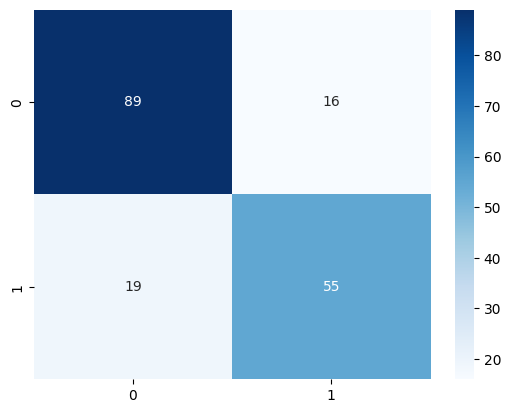

In [117]:
print(accuracy_score(y_test, y_pred))
print(sn.heatmap(confusion_matrix(y_test, y_pred), annot= True, cmap= 'Blues'))